In [1]:
# Import required libraries
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

# Check dataset shape
print("Dataset shape:", df.shape)

# Preview first rows
df.head()


Dataset shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [2]:
# Display column names, data types, and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [3]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Display duplicate rows if they exist
if duplicate_count > 0:
    duplicate_rows = df[df.duplicated(keep=False)]
    display(duplicate_rows)


Number of duplicate rows: 0


In [4]:
# Count missing values per column
null_values = df.isna().sum()
print("Missing values per column:\n")
print(null_values[null_values > 0])

# Display rows containing at least one missing value
rows_with_nulls = df[df.isna().any(axis=1)]
print("\nRows containing missing values:", rows_with_nulls.shape[0])
display(rows_with_nulls.head(10))


Missing values per column:

bmi    201
dtype: int64

Rows containing missing values: 201


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
13,8213,Male,78.0,0,1,Yes,Private,Urban,219.84,NaN,Unknown,1
19,25226,Male,57.0,0,1,No,Govt_job,Urban,217.08,NaN,Unknown,1
27,61843,Male,58.0,0,0,Yes,Private,Rural,189.84,NaN,Unknown,1
29,69160,Male,59.0,0,0,Yes,Private,Rural,211.78,NaN,formerly smoked,1
43,1845,Female,63.0,0,0,Yes,Private,Urban,90.90,NaN,formerly smoked,1
46,37937,Female,75.0,0,1,No,Self-employed,Urban,109.78,NaN,Unknown,1
50,18587,Female,76.0,0,0,No,Private,Urban,89.96,NaN,Unknown,1
51,15102,Male,78.0,1,0,Yes,Private,Urban,75.32,NaN,formerly smoked,1


In [5]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include="object").columns

# Remove leading/trailing spaces from text data
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

# Verify unique values count after cleaning
df[categorical_cols].nunique()


,0
gender,3
ever_married,2
work_type,5
Residence_type,2
smoking_status,4


In [6]:
# Convert 'Unknown' smoking status to NaN
df["smoking_status"] = df["smoking_status"].replace("Unknown", np.nan)

# Check how many values became missing
print("Missing smoking_status values:", df["smoking_status"].isna().sum())

# Display affected rows
display(df[df["smoking_status"].isna()].head(10))


Missing smoking_status values: 1544


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,NaN,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,NaN,1
13,8213,Male,78.0,0,1,Yes,Private,Urban,219.84,NaN,NaN,1
19,25226,Male,57.0,0,1,No,Govt_job,Urban,217.08,NaN,NaN,1
23,64778,Male,82.0,0,1,Yes,Private,Rural,208.30,32.5,NaN,1
27,61843,Male,58.0,0,0,Yes,Private,Rural,189.84,NaN,NaN,1
31,33879,Male,42.0,0,0,Yes,Private,Rural,83.41,25.4,NaN,1
38,47306,Male,58.0,0,0,No,Private,Rural,92.62,32.0,NaN,1
46,37937,Female,75.0,0,1,No,Self-employed,Urban,109.78,NaN,NaN,1
50,18587,Female,76.0,0,0,No,Private,Urban,89.96,NaN,NaN,1


In [7]:
# Check missing BMI values before imputation
print("Missing BMI before:", df["bmi"].isna().sum())

# Fill missing BMI with median value
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

# Check missing BMI values after imputation
print("Missing BMI after:", df["bmi"].isna().sum())


Missing BMI before: 201
Missing BMI after: 0


In [8]:
# Check missing smoking status before filling
print("Missing smoking_status before:", df["smoking_status"].isna().sum())

# Fill missing smoking status using most frequent value (mode)
df["smoking_status"] = df["smoking_status"].fillna(df["smoking_status"].mode()[0])

# Verify result
print("Missing smoking_status after:", df["smoking_status"].isna().sum())


Missing smoking_status before: 1544
Missing smoking_status after: 0


In [9]:
# Drop ID column as it has no predictive value
if "id" in df.columns:
    df = df.drop(columns=["id"])

print("Shape after dropping ID column:", df.shape)


Shape after dropping ID column: (5110, 11)


In [10]:
# Final check for missing values
print("Remaining missing values:\n", df.isna().sum())

# Final duplicate check
print("Remaining duplicate rows:", df.duplicated().sum())

# Preview cleaned dataset
df.head()


Remaining missing values:
 gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64
Remaining duplicate rows: 0


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


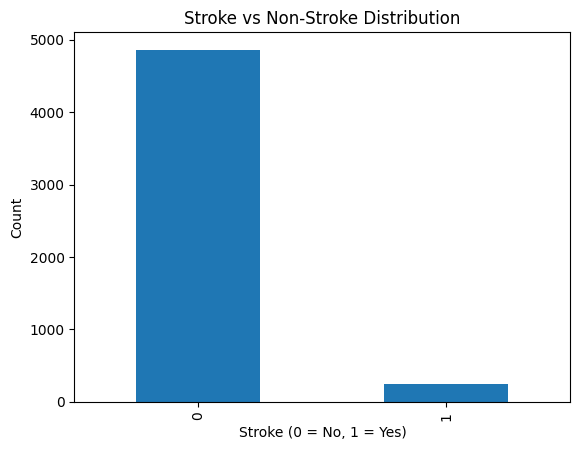

In [11]:
# Plot the distribution of the target variable (stroke)
# This helps identify class imbalance

import matplotlib.pyplot as plt

plt.figure()
df["stroke"].value_counts().plot(kind="bar")
plt.title("Stroke vs Non-Stroke Distribution")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


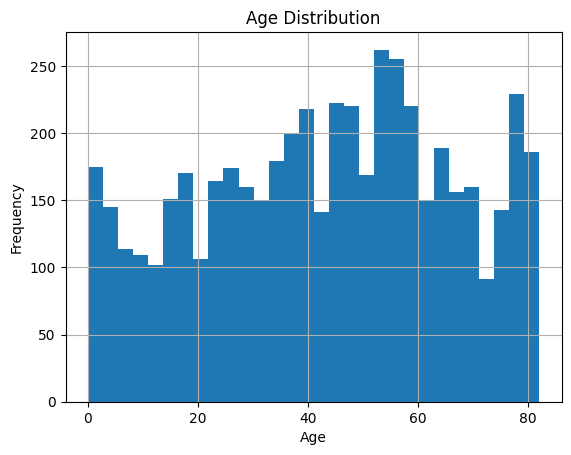

In [12]:
# Plot age distribution to understand population spread

plt.figure()
df["age"].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


<Figure size 640x480 with 0 Axes>

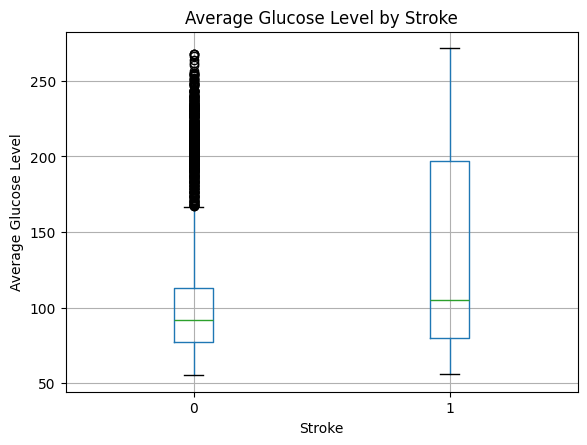

In [14]:
# Analyze glucose levels for stroke vs non-stroke cases

plt.figure()
df.boxplot(column="avg_glucose_level", by="stroke")
plt.title("Average Glucose Level by Stroke")
plt.suptitle("")
plt.xlabel("Stroke")
plt.ylabel("Average Glucose Level")
plt.show()


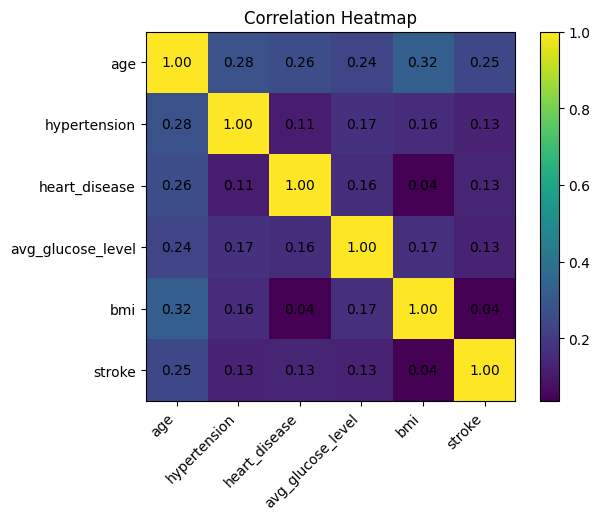

In [15]:
# Correlation heatmap for numerical features
# Helps understand linear relationships with stroke

numeric_df = df.select_dtypes(include=["int64", "float64"])
corr = numeric_df.corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")

# Annotate correlation values inside heatmap
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center")

plt.show()


<Figure size 640x480 with 0 Axes>

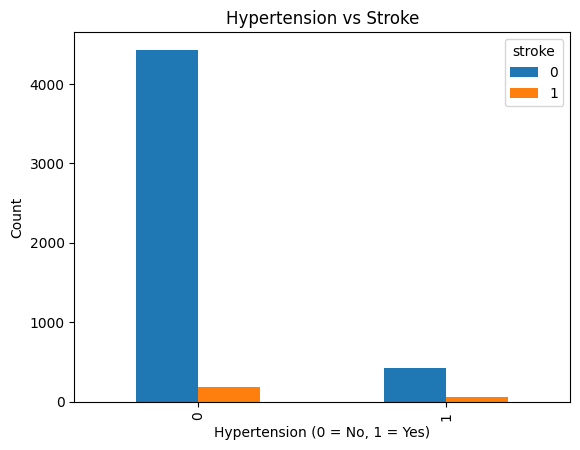

In [16]:
# Compare stroke occurrence based on hypertension status

plt.figure()
pd.crosstab(df["hypertension"], df["stroke"]).plot(kind="bar")
plt.title("Hypertension vs Stroke")
plt.xlabel("Hypertension (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


In [17]:
# Separate input features (X) and target variable (y)

X = df.drop(columns=["stroke"])
y = df["stroke"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (5110, 10)
y shape: (5110,)


In [18]:
# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder

# Create a copy to avoid modifying original dataframe
X_encoded = X.copy()

# Identify categorical columns
categorical_cols = X_encoded.select_dtypes(include="object").columns

# Apply Label Encoding to each categorical column
le = LabelEncoder()
for col in categorical_cols:
    X_encoded[col] = le.fit_transform(X_encoded[col])

# Verify encoding
X_encoded.head()


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,1,67.0,0,1,1,2,1,228.69,36.6,0
1,0,61.0,0,0,1,3,0,202.21,28.1,1
2,1,80.0,0,1,1,2,0,105.92,32.5,1
3,0,49.0,0,0,1,2,1,171.23,34.4,2
4,0,79.0,1,0,1,3,0,174.12,24.0,1


In [19]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
# Stratify ensures stroke imbalance is preserved

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (4088, 10)
Test set: (1022, 10)


In [20]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

print("Scaling completed")


Scaling completed


In [21]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE ONLY on training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled, y_train
)

# Check new class distribution
print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_smote.value_counts())


Before SMOTE:
 stroke
0    3889
1     199
Name: count, dtype: int64

After SMOTE:
 stroke
0    3889
1    3889
Name: count, dtype: int64


In [22]:
# XGBoost model for stroke prediction

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

# Train model on SMOTE-balanced data
xgb_model.fit(X_train_smote, y_train_smote)

# Predict on test data
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Evaluation
print("XGBoost Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb))


XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       972
           1       0.18      0.24      0.21        50

    accuracy                           0.91      1022
   macro avg       0.57      0.59      0.58      1022
weighted avg       0.92      0.91      0.92      1022

Confusion Matrix:

[[917  55]
 [ 38  12]]


In [23]:
# Naive Bayes model

from sklearn.naive_bayes import GaussianNB

# Initialize model
nb_model = GaussianNB()

# Train model
nb_model.fit(X_train_smote, y_train_smote)

# Predict on test data
y_pred_nb = nb_model.predict(X_test_scaled)

# Evaluation
print("Naive Bayes Classification Report:\n")
print(classification_report(y_test, y_pred_nb))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_nb))


Naive Bayes Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.73      0.84       972
           1       0.13      0.74      0.21        50

    accuracy                           0.73      1022
   macro avg       0.55      0.74      0.53      1022
weighted avg       0.94      0.73      0.81      1022

Confusion Matrix:

[[714 258]
 [ 13  37]]


In [29]:
# ================================
# Decision Tree: Training & Evaluation
# ================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Initialize Decision Tree classifier
# max_depth is used to control overfitting
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train the model using SMOTE-balanced training data
dt_model.fit(X_train_smote, y_train_smote)

# Predict class labels on the scaled test dataset
y_pred_dt = dt_model.predict(X_test_scaled)

# Display classification report
# Includes precision, recall, F1-score, and support
print("Classification Report - Decision Tree:\n")
print(classification_report(y_test, y_pred_dt))


Classification Report - Decision Tree:

              precision    recall  f1-score   support

           0       0.99      0.76      0.86       972
           1       0.15      0.80      0.25        50

    accuracy                           0.76      1022
   macro avg       0.57      0.78      0.55      1022
weighted avg       0.95      0.76      0.83      1022



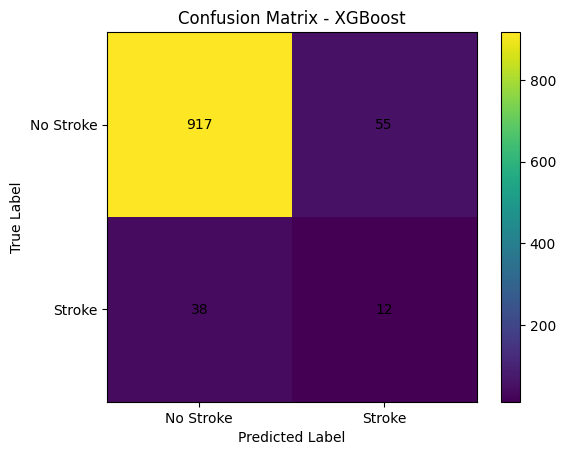

In [26]:
# Import required function
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate confusion matrix for XGBoost predictions
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Create plot
plt.figure()
plt.imshow(cm_xgb)
plt.title("Confusion Matrix - XGBoost")
plt.colorbar()

# Label axes
plt.xticks([0, 1], ["No Stroke", "Stroke"])
plt.yticks([0, 1], ["No Stroke", "Stroke"])

# Annotate values inside the matrix
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_xgb[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


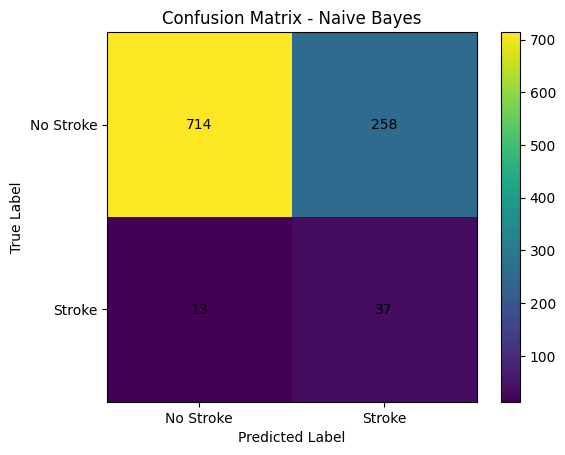

In [27]:
# Generate confusion matrix for Naive Bayes predictions
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure()
plt.imshow(cm_nb)
plt.title("Confusion Matrix - Naive Bayes")
plt.colorbar()

plt.xticks([0, 1], ["No Stroke", "Stroke"])
plt.yticks([0, 1], ["No Stroke", "Stroke"])

# Annotate matrix values
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_nb[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


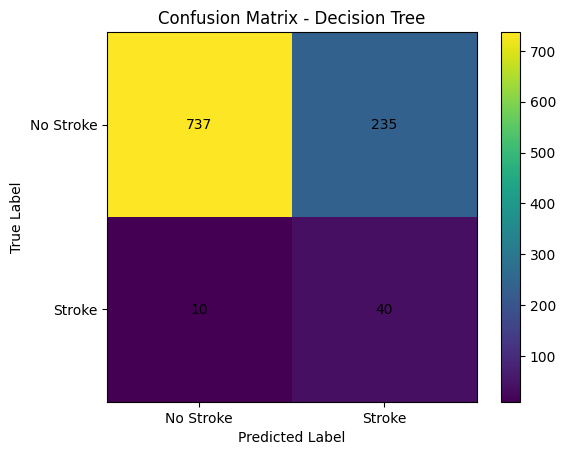

In [30]:
# ==================================
# Confusion Matrix Plot - Decision Tree
# ==================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate confusion matrix using true and predicted labels
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Create the plot
plt.figure()
plt.imshow(cm_dt)
plt.title("Confusion Matrix - Decision Tree")
plt.colorbar()

# Label axis ticks
plt.xticks([0, 1], ["No Stroke", "Stroke"])
plt.yticks([0, 1], ["No Stroke", "Stroke"])

# Annotate each cell with its value
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_dt[i, j],
                 ha="center", va="center")

# Label axes
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Display plot
plt.show()


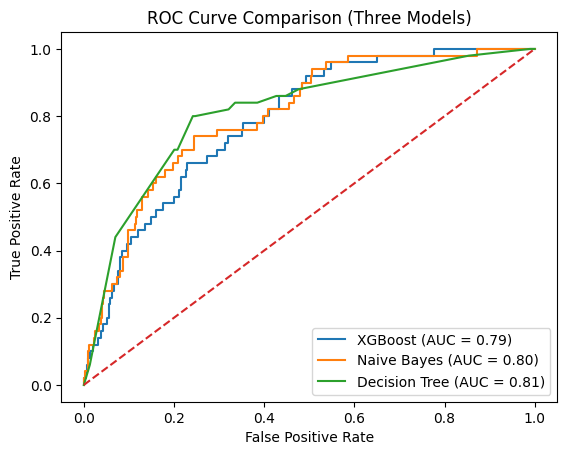

In [31]:
# ==========================================================
# ROC–AUC Curve Comparison (XGBoost vs Naive Bayes vs DT)
# ==========================================================
# Assumes you already have:
#   xgb_model, nb_model, dt_model
#   X_test_scaled, y_test
# Uses predicted probabilities to compute ROC and AUC.

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ---------- XGBoost probabilities ----------
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# ---------- Naive Bayes probabilities ----------
y_prob_nb = nb_model.predict_proba(X_test_scaled)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_nb = roc_auc_score(y_test, y_prob_nb)

# ---------- Decision Tree probabilities ----------
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

# ---------- Plot all ROC curves in ONE plot ----------
plt.figure()

plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.2f})")
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc_nb:.2f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.2f})")

# Random classifier reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison (Three Models)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [32]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import numpy as np

from xgboost import XGBClassifier

# Pipeline: scale -> SMOTE -> model (prevents CV leakage)
pipe_xgb = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(random_state=42, eval_metric="logloss"))
])

# Parameter search space (RandomizedSearch = faster)
param_dist_xgb = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__gamma": [0, 0.1, 0.2, 0.5],
    "model__reg_alpha": [0, 0.1, 1.0],
    "model__reg_lambda": [1.0, 2.0, 5.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search_xgb = RandomizedSearchCV(
    estimator=pipe_xgb,
    param_distributions=param_dist_xgb,
    n_iter=25,                  # increase if you want deeper search
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search_xgb.fit(X_train, y_train)

print("Best ROC-AUC (CV):", search_xgb.best_score_)
print("Best Params:", search_xgb.best_params_)

best_xgb = search_xgb.best_estimator_


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best ROC-AUC (CV): 0.8068934430631088
Best Params: {'model__subsample': 0.8, 'model__reg_lambda': 1.0, 'model__reg_alpha': 0.1, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 0.7}


In [33]:
from sklearn.naive_bayes import GaussianNB

pipe_nb = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", GaussianNB())
])

param_dist_nb = {
    "model__var_smoothing": np.logspace(-12, -6, 20)  # common tuning range
}

search_nb = RandomizedSearchCV(
    estimator=pipe_nb,
    param_distributions=param_dist_nb,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search_nb.fit(X_train, y_train)

print("Best ROC-AUC (CV):", search_nb.best_score_)
print("Best Params:", search_nb.best_params_)

best_nb = search_nb.best_estimator_


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best ROC-AUC (CV): 0.815080400678087
Best Params: {'model__var_smoothing': np.float64(1e-12)}


In [34]:
from sklearn.tree import DecisionTreeClassifier

pipe_dt = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", DecisionTreeClassifier(random_state=42))
])

param_dist_dt = {
    "model__max_depth": [None, 3, 5, 7, 10, 15],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__criterion": ["gini", "entropy", "log_loss"],
    "model__max_features": [None, "sqrt", "log2"]
}

search_dt = RandomizedSearchCV(
    estimator=pipe_dt,
    param_distributions=param_dist_dt,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search_dt.fit(X_train, y_train)

print("Best ROC-AUC (CV):", search_dt.best_score_)
print("Best Params:", search_dt.best_params_)

best_dt = search_dt.best_estimator_


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best ROC-AUC (CV): 0.7961123939979982
Best Params: {'model__min_samples_split': 20, 'model__min_samples_leaf': 4, 'model__max_features': None, 'model__max_depth': 3, 'model__criterion': 'log_loss'}


In [35]:
# ==================================================
# Classification Reports: XGBoost, Naive Bayes, DT
# ==================================================

from sklearn.metrics import classification_report

# ----- XGBoost -----
y_pred_xgb = best_xgb.predict(X_test)
print("Classification Report - XGBoost\n")
print(classification_report(y_test, y_pred_xgb))
print("-" * 60)

# ----- Naive Bayes -----
y_pred_nb = best_nb.predict(X_test)
print("Classification Report - Naive Bayes\n")
print(classification_report(y_test, y_pred_nb))
print("-" * 60)

# ----- Decision Tree -----
y_pred_dt = best_dt.predict(X_test)
print("Classification Report - Decision Tree\n")
print(classification_report(y_test, y_pred_dt))


Classification Report - XGBoost

              precision    recall  f1-score   support

           0       0.98      0.85      0.91       972
           1       0.18      0.64      0.29        50

    accuracy                           0.84      1022
   macro avg       0.58      0.75      0.60      1022
weighted avg       0.94      0.84      0.88      1022

------------------------------------------------------------
Classification Report - Naive Bayes

              precision    recall  f1-score   support

           0       0.98      0.73      0.84       972
           1       0.13      0.74      0.21        50

    accuracy                           0.73      1022
   macro avg       0.55      0.74      0.53      1022
weighted avg       0.94      0.73      0.81      1022

------------------------------------------------------------
Classification Report - Decision Tree

              precision    recall  f1-score   support

           0       0.99      0.74      0.84       972
      